In [2]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
random.seed(0)

%matplotlib inline
g = torch.Generator().manual_seed(0)

with open('../names.txt', 'r') as f:
    words = f.read().splitlines()
    

In [3]:
# define mapping from character to their numerical equivalent and back
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
# also add '.' as index 0
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(chars)+1
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [4]:
# build the dataset

block_size = 3 # context length

def build_dataset(words:list)->tuple:
    X, Y  =[], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context),'---->',itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])


In [9]:
# Create Multi-layer perceptron
n_embed = 10
n_hidden = 200
C   = torch.randn((27,n_embed),     generator=g) 
W1  = torch.randn((30,n_hidden),    generator=g) * (5/3)/((n_embed * block_size) ** 0.5)
# b1  = torch.randn(n_hidden,         generator=g) * 0
W2  = torch.randn((200,vocab_size), generator=g) * 0.02
b2  = torch.randn(vocab_size,       generator=g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


In [10]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [11]:
# During our last implementation we saw a large loss value initially that decreased over iterations, making a hockey stick appearance loss curve
# In this implementation, we try to solve that based on initlaization methods
# First initialization is multiplying biases by 0 and weights by 0.01
# We do not set the weights to zeros 
# Without initialization, the loss starts from 30 and goes to 2.51 after 100000 iteration
# Using initialization, loss starts from 4 and goes to 2.13

In [12]:
max_steps = 100000
batch_size = 32
lossi = []
stepi = []

for i in range(max_steps):
    # Minibatch sampling
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]
    
    # Forward pass
    emb = C[Xb]  # (32, 3, 2)
    embcat = emb.view(emb.shape[0], -1)
    # Linear layer
    hpreact = embcat @ W1 #+ b1
    # BatchNorm layer
    # ----------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) +bnbias # batch normalization
    # we want the distribution to be roughly gaussian but not forced 
    # to be gaussaian. we want the neural network to be able to move
    # shift, etc -> thorugh bn bias
    # BN has its own bias, no need to add biad in the weight before it
    
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnbias
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # ----------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact)  # (32, hidden_dim)
    logits = h @ W2 + b2  # (32, output_dim)
    loss = F.cross_entropy(logits, Yb)
    
    if i%10000 == 0:
        print(f'Iteration {i}/{100000}: Loss = {loss.item()}')

    # Zero gradients
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update parameters with learning rate
    lr = 0.1 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

Iteration 0/100000: Loss = 3.302462577819824
Iteration 10000/100000: Loss = 2.625805616378784
Iteration 20000/100000: Loss = 1.888468861579895
Iteration 30000/100000: Loss = 2.5555853843688965
Iteration 40000/100000: Loss = 2.4527463912963867
Iteration 50000/100000: Loss = 2.135601043701172
Iteration 60000/100000: Loss = 2.240159034729004
Iteration 70000/100000: Loss = 2.4353888034820557
Iteration 80000/100000: Loss = 2.102891445159912
Iteration 90000/100000: Loss = 2.2995705604553223


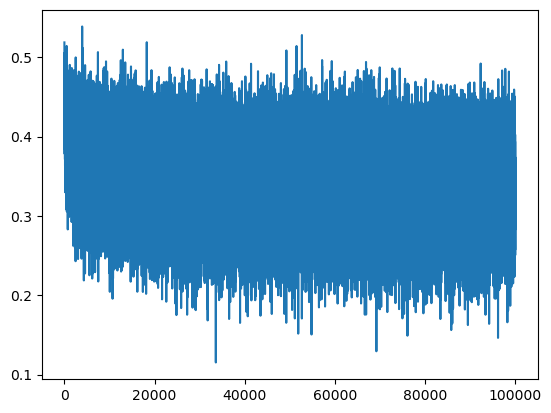

In [13]:
plt.plot(stepi, lossi)

In [33]:
# Second problem:
# activation of hidden states
# many elements are 1 or -1, tanh is squashing function
# it takes range of values and squashed it into range of -1 to 1

In [34]:
# dead neuron if columns completely white i.e value 1 for whole column
# this problem can occur in other networks like relu 
# can happen during initalization, learning higher learning rate
# can find neuron that never activate

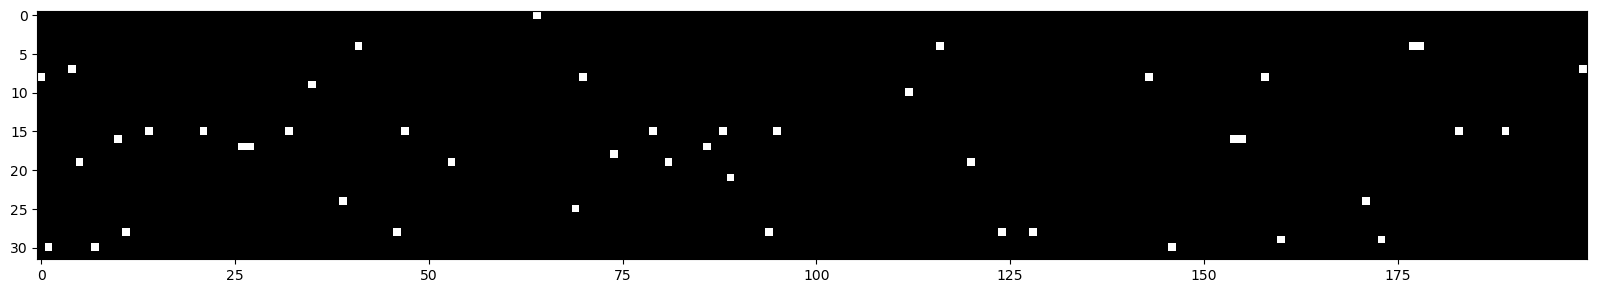

In [35]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation='nearest')

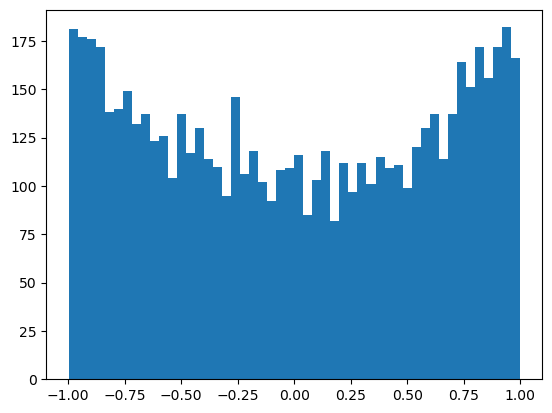

In [36]:
plt.hist(h.view(-1).tolist(), 50);

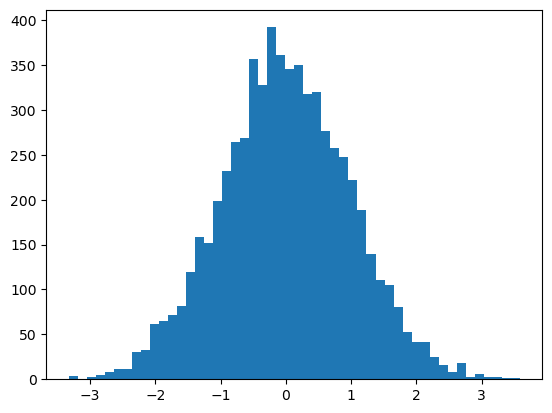

In [37]:
plt.hist(hpreact.view(-1).tolist(), 50 );

In [38]:
# kaiming normal for tanh
(5/3) / (30**0.5)

0.3042903097250923

tensor(-0.0045) tensor(1.0028)
tensor(-0.0003) tensor(1.0355)


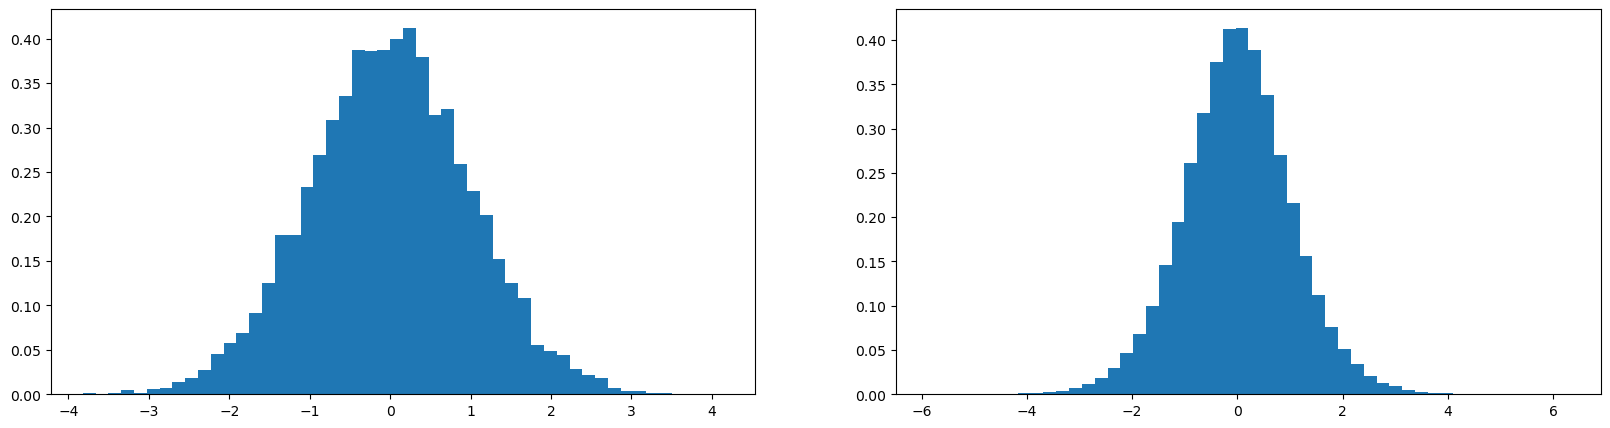

In [39]:
x = torch.randn(1000,10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [40]:
# mean remains the same , but the std has changed to 3. i.e expanding
# we want unit gaussian throught the neural net
# if we multiplu w ith numbers 0-1, gaussian std decreases
# so, what do i multiply, to get std 1?
# divide by square root of the fan in

In [41]:
# how to initializze the weights so activation stays relative to zeris?
# kaiming normal
# depending on non-linearty, slightly different fan in
# 

In [42]:
## Batch normalization
# how to feed single input, and get single batch out as batch norm calculates mean and std in batches?


In [44]:
# calibrate tge batchnorm at the end of training
with torch.no_grad():
    emb = C[X_train]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

## Loss of model

In [45]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train':(X_train, Y_train),
        'val': (X_val, Y_val),
        'test':(X_test, Y_test),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd +bnbias
    h = torch.tanh(hpreact)
    logits = h@ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
split_loss('train')
split_loss('val')

train 2.156808853149414
val 2.1951191425323486


In [36]:
# training loss
emb = C[X_train]
h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
loss

tensor(2.1126, grad_fn=<NllLossBackward0>)

In [37]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
loss

tensor(2.1673, grad_fn=<NllLossBackward0>)

In [38]:
emb = C[X_test]
h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)
loss

tensor(2.1633, grad_fn=<NllLossBackward0>)

In [40]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

mona.
kayah.
see.
mad.
ryla.
rethan.
ejgraeg.
aderedielin.
shi.
jenleigh.
vananarielle.
malara.
noshubergias.
jest.
jair.
jelina.
terorius.
kavdi.
kylene.
els.
